# Module 2: Banking — Credit Risk & Fraud Detection
## Aurora Finance | ML-Driven Decision Support

**Objective:** Assess Aurora's loan portfolio and detect fraudulent transactions by:
1. Predicting Probability of Default (PD) using regression models
2. Classifying high-risk loans using binary classification
3. Detecting fraudulent transactions with supervised and unsupervised methods
4. Producing risk-scored outputs for lending officers

**Datasets:**
- `loan_portfolio.csv` — 100 loans with applicant financials and PD labels
- `transactions.csv` — 200 transactions with fraud flags (4.5% fraud rate — severe imbalance)

In [6]:
import subprocess
pkgs = ["xgboost", "shap", "seaborn", "scikit-learn", "matplotlib",
        "pandas", "numpy", "imbalanced-learn"]
subprocess.run(["pip", "install"] + pkgs + ["-q"], check=True)
print("Dependencies ready.")

Dependencies ready.


In [7]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import cross_validate, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               IsolationForest, GradientBoostingClassifier)
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              roc_auc_score, f1_score, accuracy_score,
                              precision_score, recall_score,
                              precision_recall_curve, average_precision_score,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.base import clone
from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE
import shap

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
RANDOM_STATE = 42

_nb_dir = os.path.dirname(os.path.abspath("module2_banking.ipynb"))
print("All libraries imported.")

All libraries imported.


---
## 1. Data Loading & Overview

In [8]:
loans = pd.read_csv(os.path.join(_nb_dir, "loan_portfolio.csv"))
txns  = pd.read_csv(os.path.join(_nb_dir, "transactions.csv"))
txns["Timestamp"] = pd.to_datetime(txns["Timestamp"])

print(f"Loans shape   : {loans.shape}")
print(f"Transactions  : {txns.shape}")
print(f"\n--- Loans ---")
display(loans.head())
print(f"\n--- Transactions (first 5) ---")
display(txns.head())

Loans shape   : (100, 10)
Transactions  : (200, 6)

--- Loans ---


,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12



--- Transactions (first 5) ---


,Transaction_ID,Customer_ID,Amount,Transaction_Type,Timestamp,Fraud_Flag
0,1,57,35200,Withdrawal,2025-09-03 10:47:51.200706,0
1,2,16,25871,Transfer,2025-12-31 10:47:51.200738,0
2,3,56,26710,Withdrawal,2025-09-12 10:47:51.200752,0
3,4,10,5134,Withdrawal,2025-03-29 10:47:51.200763,0
4,5,30,16711,Transfer,2025-06-08 10:47:51.200773,0


In [9]:
print("=== Loan Portfolio Summary ===")
display(loans.describe().round(3))
print(f"\nCustomer Type  : {loans['Customer_Type'].value_counts().to_dict()}")
print(f"Past Default   : {loans['Past_Default'].sum()} / {len(loans)} ({loans['Past_Default'].mean():.1%})")
print(f"PD range       : {loans['PD'].min():.3f} – {loans['PD'].max():.3f} | mean {loans['PD'].mean():.3f}")

print("\n=== Transactions Summary ===")
display(txns.describe().round(2))
print(f"\nTransaction types : {txns['Transaction_Type'].value_counts().to_dict()}")
print(f"Fraud cases       : {txns['Fraud_Flag'].sum()} / {len(txns)} ({txns['Fraud_Flag'].mean():.1%})")
print(f"Amount range      : ${txns['Amount'].min():,} – ${txns['Amount'].max():,}")

=== Loan Portfolio Summary ===


,Loan_ID,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD
count,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000
mean,50.500,2671591.570,0.554,13.010,509767.280,9.069,34.920,0.130,0.157
std,29.011,1444021.046,0.243,7.116,273871.762,3.356,17.149,0.338,0.089
min,1.000,56790.000,0.110,1.000,11062.000,3.400,12.000,0.000,0.010
25%,25.750,1366360.750,0.372,6.000,274199.500,6.040,24.000,0.000,0.080
50%,50.500,2778969.000,0.570,14.500,544523.500,9.185,36.000,0.000,0.165
75%,75.250,3980000.750,0.780,19.000,720938.750,12.170,48.000,0.000,0.232
max,100.000,4969003.000,0.900,24.000,965614.000,14.880,60.000,1.000,0.300



Customer Type  : {'Retail': 53, 'Corporate': 47}
Past Default   : 13 / 100 (13.0%)
PD range       : 0.010 – 0.300 | mean 0.157

=== Transactions Summary ===


,Transaction_ID,Customer_ID,Amount,Timestamp,Fraud_Flag
count,200.00,200.00,200.00,200,200.00
mean,100.50,52.50,25462.71,2025-07-27 19:11:51.201649664,0.04
min,1.00,2.00,155.00,2025-01-26 10:47:51.201107,0.00
25%,50.75,30.00,13495.50,2025-04-18 04:47:51.201208576,0.00
50%,100.50,55.00,25802.00,2025-08-19 22:47:51.201696512,0.00
75%,150.25,76.25,36254.00,2025-10-26 04:47:51.201142016,0.00
max,200.00,100.00,49980.00,2026-01-25 10:47:51.200829,1.00
std,57.88,28.74,14087.35,NaN,0.21



Transaction types : {'Withdrawal': 69, 'Payment': 67, 'Transfer': 64}
Fraud cases       : 9 / 200 (4.5%)
Amount range      : $155 – $49,980


---
## 2. Exploratory Data Analysis — Loan Portfolio

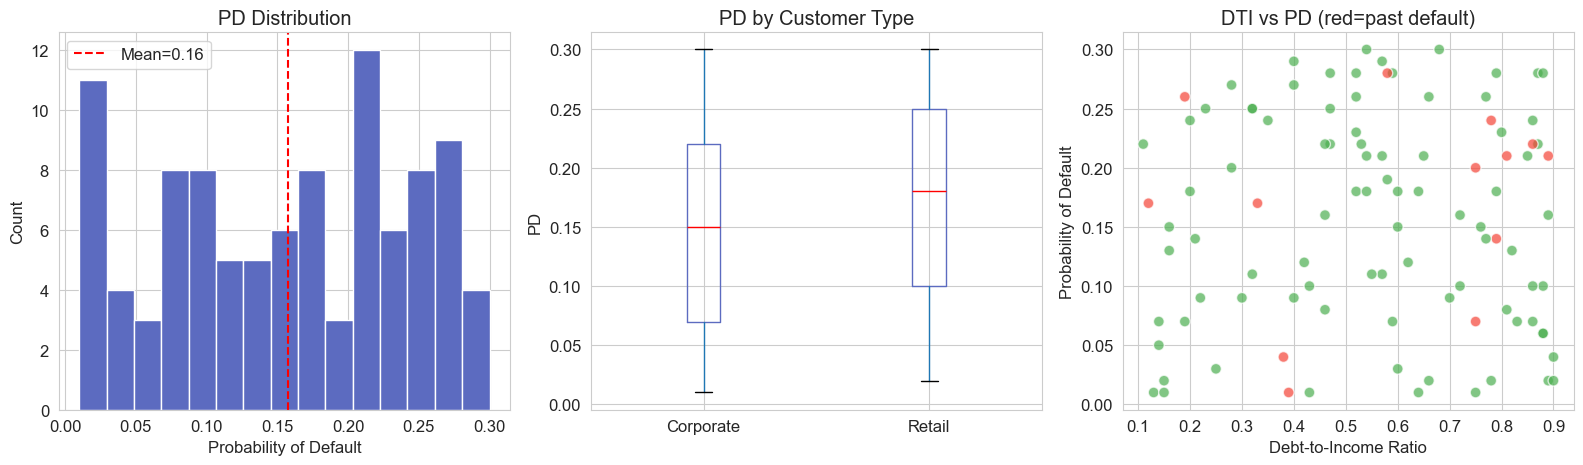

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# PD distribution
axes[0].hist(loans["PD"], bins=15, color="#5C6BC0", edgecolor="white")
axes[0].set_title("PD Distribution"); axes[0].set_xlabel("Probability of Default"); axes[0].set_ylabel("Count")
axes[0].axvline(loans["PD"].mean(), color="red", linestyle="--", label=f"Mean={loans['PD'].mean():.2f}")
axes[0].legend()

# PD by Customer Type
loans.boxplot(column="PD", by="Customer_Type", ax=axes[1],
              boxprops=dict(color="#5C6BC0"), medianprops=dict(color="red"))
axes[1].set_title("PD by Customer Type"); axes[1].set_xlabel(""); axes[1].set_ylabel("PD")
plt.sca(axes[1]); plt.title("PD by Customer Type")

# DTI vs PD scatter
scatter_col = loans["Past_Default"].map({0:"#4CAF50", 1:"#F44336"})
axes[2].scatter(loans["Debt_to_Income"], loans["PD"],
                c=scatter_col, alpha=0.7, s=60, edgecolors="white")
axes[2].set_xlabel("Debt-to-Income Ratio"); axes[2].set_ylabel("Probability of Default")
axes[2].set_title("DTI vs PD (red=past default)")

plt.suptitle("")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "loan_eda_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

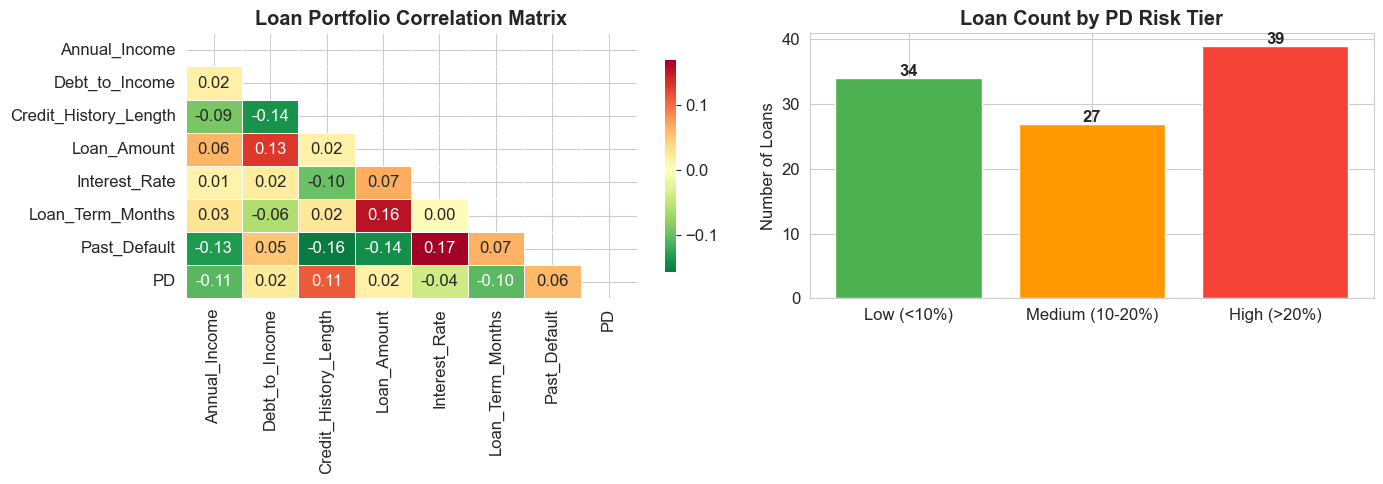

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
from matplotlib.patches import Patch

# Correlation heatmap
num_cols = ["Annual_Income","Debt_to_Income","Credit_History_Length",
            "Loan_Amount","Interest_Rate","Loan_Term_Months","Past_Default","PD"]
corr = loans[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, ax=axes[0], linewidths=0.5, cbar_kws={"shrink":0.8})
axes[0].set_title("Loan Portfolio Correlation Matrix", fontweight="bold")

# PD distribution by risk bucket
loans["PD_Tier"] = pd.cut(loans["PD"],
                            bins=[0, 0.10, 0.20, 1.0],
                            labels=["Low (<10%)", "Medium (10-20%)", "High (>20%)"])
tier_counts = loans["PD_Tier"].value_counts().reindex(["Low (<10%)","Medium (10-20%)","High (>20%)"])
colors_tier = ["#4CAF50", "#FF9800", "#F44336"]
axes[1].bar(tier_counts.index, tier_counts.values, color=colors_tier, edgecolor="white")
axes[1].set_title("Loan Count by PD Risk Tier", fontweight="bold")
axes[1].set_ylabel("Number of Loans")
for i, v in enumerate(tier_counts.values): axes[1].text(i, v+0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "loan_eda_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Exploratory Data Analysis — Transactions

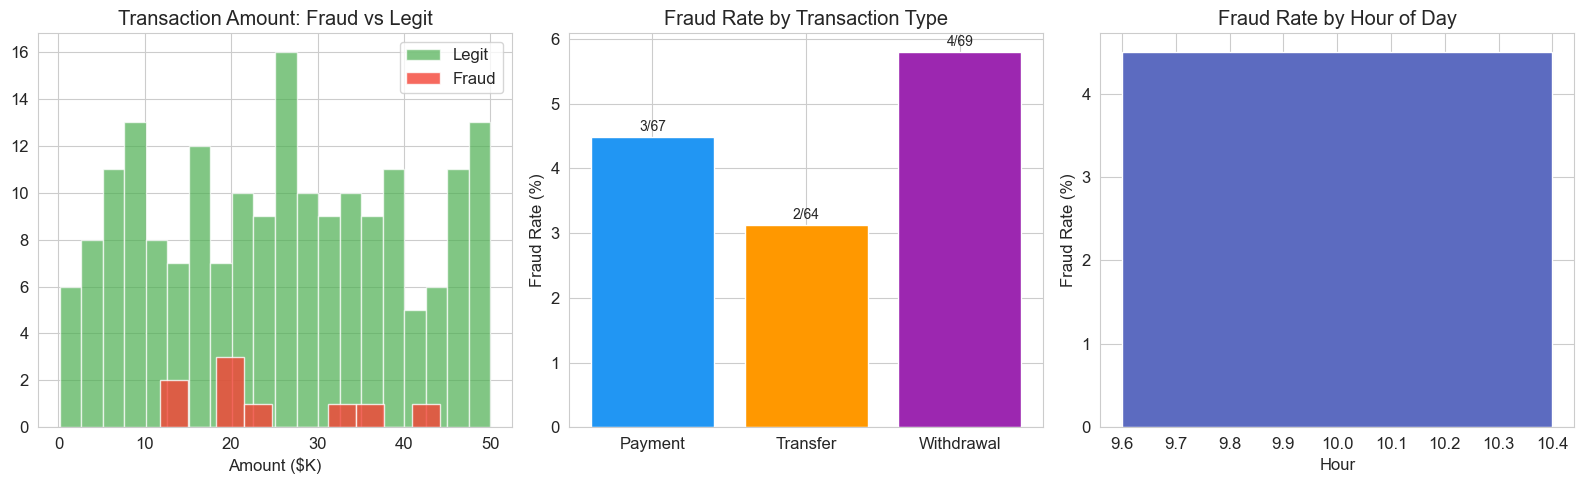

NOTE: Only 9 fraud cases out of 200 (4.5%) — severe class imbalance.


In [12]:
txns["Hour"]       = txns["Timestamp"].dt.hour
txns["DayOfWeek"]  = txns["Timestamp"].dt.dayofweek
txns["IsWeekend"]  = (txns["DayOfWeek"] >= 5).astype(int)
txns["IsNight"]    = ((txns["Hour"] < 6) | (txns["Hour"] >= 22)).astype(int)
txns["log_Amount"] = np.log1p(txns["Amount"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
from matplotlib.patches import Patch

# Amount distribution by fraud flag
axes[0].hist(txns[txns["Fraud_Flag"]==0]["Amount"]/1000, bins=20,
             alpha=0.7, color="#4CAF50", label="Legit", edgecolor="white")
axes[0].hist(txns[txns["Fraud_Flag"]==1]["Amount"]/1000, bins=10,
             alpha=0.8, color="#F44336", label="Fraud", edgecolor="white")
axes[0].set_title("Transaction Amount: Fraud vs Legit"); axes[0].set_xlabel("Amount ($K)")
axes[0].legend()

# Fraud by Transaction Type
fraud_by_type = txns.groupby("Transaction_Type")["Fraud_Flag"].agg(["sum","count"])
fraud_by_type["rate"] = fraud_by_type["sum"] / fraud_by_type["count"]
colors_type = ["#2196F3","#FF9800","#9C27B0"]
bars = axes[1].bar(fraud_by_type.index, fraud_by_type["rate"]*100, color=colors_type, edgecolor="white")
axes[1].set_title("Fraud Rate by Transaction Type"); axes[1].set_ylabel("Fraud Rate (%)")
for bar, (_, row) in zip(bars, fraud_by_type.iterrows()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{row['sum']:.0f}/{row['count']:.0f}", ha="center", fontsize=10)

# Fraud by hour
fraud_by_hour = txns.groupby("Hour")["Fraud_Flag"].mean() * 100
axes[2].bar(fraud_by_hour.index, fraud_by_hour.values, color="#5C6BC0", edgecolor="white")
axes[2].set_title("Fraud Rate by Hour of Day"); axes[2].set_xlabel("Hour"); axes[2].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "txn_eda.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"NOTE: Only {txns['Fraud_Flag'].sum()} fraud cases out of {len(txns)} ({txns['Fraud_Flag'].mean():.1%}) — severe class imbalance.")

---
## 4. Feature Engineering — Loans

**Set A - Raw encoded:** Customer_Type (encoded), numeric columns as-is

**Set B - Engineered:** Set A + derived financial ratios

| Feature | Formula | Business Meaning |
|---|---|---|
| `Loan_to_Income` | Loan_Amount / Annual_Income | Affordability — how large is loan vs income |
| `Monthly_Payment_Est` | Loan_Amount / Loan_Term_Months | Rough monthly obligation |
| `Payment_to_Income` | Monthly_Payment / (Annual_Income/12) | Monthly burden on borrower |
| `DTI_Credit_Interact` | Debt_to_Income / (Credit_History_Length + 1) | DTI weighted by credit maturity |
| `Risk_Index` | 0.5*DTI + 0.3*Past_Default + 0.2*(1/Credit_Hist) | Composite risk score |
| `log_Income` | log(Annual_Income) | Normalises skewed income distribution |
| `Rate_Sensitivity` | Interest_Rate * Loan_Term_Months / 12 | Total interest burden proxy |

In [13]:
loans_feat = loans.copy()

# Encode Customer_Type
loans_feat["Is_Corporate"] = (loans_feat["Customer_Type"] == "Corporate").astype(int)

# Set B engineered features
loans_feat["Loan_to_Income"]      = loans_feat["Loan_Amount"] / loans_feat["Annual_Income"]
loans_feat["Monthly_Payment_Est"] = loans_feat["Loan_Amount"] / loans_feat["Loan_Term_Months"]
loans_feat["Payment_to_Income"]   = loans_feat["Monthly_Payment_Est"] / (loans_feat["Annual_Income"] / 12)
loans_feat["DTI_Credit_Interact"] = loans_feat["Debt_to_Income"] / (loans_feat["Credit_History_Length"] + 1)
loans_feat["Risk_Index"]          = (0.5 * loans_feat["Debt_to_Income"] +
                                      0.3 * loans_feat["Past_Default"] +
                                      0.2 * (1 / (loans_feat["Credit_History_Length"] + 1)))
loans_feat["log_Income"]          = np.log1p(loans_feat["Annual_Income"])
loans_feat["Rate_Sensitivity"]    = loans_feat["Interest_Rate"] * loans_feat["Loan_Term_Months"] / 12

print("Loan feature engineering complete.")
loans_feat[["Loan_ID","Loan_to_Income","Payment_to_Income","Risk_Index","Rate_Sensitivity"]].head()

Loan feature engineering complete.


,Loan_ID,Loan_to_Income,Payment_to_Income,Risk_Index,Rate_Sensitivity
0,1,0.149281,0.049760,0.247500,40.17
1,2,0.301131,0.100377,0.083333,38.40
2,3,0.017208,0.004302,0.112500,24.36
3,4,0.022952,0.005738,0.128333,20.20
4,5,6.029358,3.014679,0.319091,22.04


In [14]:
# Feature sets for loans
RAW_LOAN = ["Is_Corporate","Annual_Income","Debt_to_Income","Credit_History_Length",
            "Loan_Amount","Interest_Rate","Loan_Term_Months","Past_Default"]

ENG_LOAN = RAW_LOAN + ["Loan_to_Income","Monthly_Payment_Est","Payment_to_Income",
                        "DTI_Credit_Interact","Risk_Index","log_Income","Rate_Sensitivity"]

TARGET_PD     = "PD"
TARGET_DEFAULT = "Past_Default"

print(f"Set A (raw)        : {len(RAW_LOAN)} features")
print(f"Set B (engineered) : {len(ENG_LOAN)} features")
print(f"Regression target  : {TARGET_PD}")
print(f"Classification target: {TARGET_DEFAULT}")

Set A (raw)        : 8 features
Set B (engineered) : 15 features
Regression target  : PD
Classification target: Past_Default


---
## 5. Feature Engineering — Transactions

**Set A - Raw:** Amount, Transaction_Type (encoded)

**Set B - Engineered:** Set A + temporal features, log-amount, z-score, high-value flag

| Feature | Formula | Business Meaning |
|---|---|---|
| `log_Amount` | log(1 + Amount) | Normalises right-skewed amounts |
| `Amount_ZScore` | (Amount - mean) / std | How unusual is this transaction size? |
| `IsNight` | Hour < 6 or Hour >= 22 | Night-time transactions = higher fraud risk |
| `IsWeekend` | DayOfWeek >= 5 | Weekend transactions |
| `Is_High_Value` | Amount > 90th percentile | Flag large transactions |
| `Hour` | Extracted from Timestamp | Time-of-day pattern |

In [15]:
txns_feat = txns.copy()

# Encode Transaction_Type
type_dummies = pd.get_dummies(txns_feat["Transaction_Type"], prefix="TType", drop_first=False)
txns_feat = pd.concat([txns_feat, type_dummies], axis=1)
type_dummy_cols = [c for c in txns_feat.columns if c.startswith("TType_")]

# Engineered features
amount_mean = txns_feat["Amount"].mean()
amount_std  = txns_feat["Amount"].std()
p90         = txns_feat["Amount"].quantile(0.90)

txns_feat["Amount_ZScore"]   = (txns_feat["Amount"] - amount_mean) / amount_std
txns_feat["Is_High_Value"]   = (txns_feat["Amount"] > p90).astype(int)

# RAW: just amount + type encoding
RAW_TXN = ["Amount"] + type_dummy_cols

# ENG: + temporal + derived
ENG_TXN = RAW_TXN + ["log_Amount","Amount_ZScore","Is_High_Value","Hour","IsNight","IsWeekend"]

TARGET_FRAUD = "Fraud_Flag"

print(f"Txn Set A (raw)       : {len(RAW_TXN)} features")
print(f"Txn Set B (engineered): {len(ENG_TXN)} features")
print(f"Fraud class balance: {txns_feat[TARGET_FRAUD].value_counts().to_dict()}")
print(f"Class imbalance ratio: {(len(txns_feat)-txns_feat[TARGET_FRAUD].sum()) / txns_feat[TARGET_FRAUD].sum():.1f}:1")

Txn Set A (raw)       : 4 features
Txn Set B (engineered): 10 features
Fraud class balance: {0: 191, 1: 9}
Class imbalance ratio: 21.2:1


---
## 6. Credit Risk — Regression (Predicting Probability of Default)

**Goal:** Predict the continuous PD score for each loan.

**Models:** Linear Regression, Ridge, Decision Tree, Random Forest, XGBoost

**Evaluation:** 5-fold CV — RMSE, MAE, R² (mean +/- std)

In [16]:
def eval_regression(models, X, y, cv, label=""):
    results = []
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    for name, model in models.items():
        sc = cross_validate(model, X, y, cv=kf,
                            scoring=["neg_root_mean_squared_error","neg_mean_absolute_error","r2"])
        results.append({
            "Model": name,
            "RMSE":  f"{-sc['test_neg_root_mean_squared_error'].mean():.4f} +/- {sc['test_neg_root_mean_squared_error'].std():.4f}",
            "MAE":   f"{-sc['test_neg_mean_absolute_error'].mean():.4f} +/- {sc['test_neg_mean_absolute_error'].std():.4f}",
            "R2":    f"{sc['test_r2'].mean():.3f} +/- {sc['test_r2'].std():.3f}",
            "_r2":   sc["test_r2"].mean()
        })
    df_r = pd.DataFrame(results).sort_values("_r2", ascending=False)
    print(f"\nPD Regression — {label}")
    display(df_r.drop(columns="_r2").reset_index(drop=True))
    return df_r

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Decision Tree":     DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost":           XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3,
                                      random_state=RANDOM_STATE, verbosity=0),
}

X_reg_A = loans_feat[RAW_LOAN].values
X_reg_B = loans_feat[ENG_LOAN].values
y_pd    = loans_feat[TARGET_PD].values

reg_A = eval_regression(reg_models, X_reg_A, y_pd, 5, "Set A - Raw Features")
reg_B = eval_regression(reg_models, X_reg_B, y_pd, 5, "Set B - Engineered Features")


PD Regression — Set A - Raw Features


,Model,RMSE,MAE,R2
0,Random Forest,0.0910 +/- 0.0103,0.0790 +/- 0.0103,-0.094 +/- 0.166
1,XGBoost,0.0918 +/- 0.0107,0.0784 +/- 0.0098,-0.120 +/- 0.207
2,Ridge Regression,0.0947 +/- 0.0112,0.0829 +/- 0.0108,-0.180 +/- 0.160
3,Linear Regression,0.0952 +/- 0.0113,0.0832 +/- 0.0110,-0.192 +/- 0.165
4,Decision Tree,0.1012 +/- 0.0204,0.0850 +/- 0.0183,-0.371 +/- 0.437



PD Regression — Set B - Engineered Features


,Model,RMSE,MAE,R2
0,Random Forest,0.0912 +/- 0.0104,0.0792 +/- 0.0104,-0.099 +/- 0.175
1,Ridge Regression,0.0962 +/- 0.0128,0.0843 +/- 0.0126,-0.223 +/- 0.233
2,XGBoost,0.0965 +/- 0.0113,0.0810 +/- 0.0099,-0.249 +/- 0.292
3,Linear Regression,0.0992 +/- 0.0143,0.0859 +/- 0.0124,-0.327 +/- 0.386
4,Decision Tree,0.1071 +/- 0.0159,0.0927 +/- 0.0123,-0.582 +/- 0.592


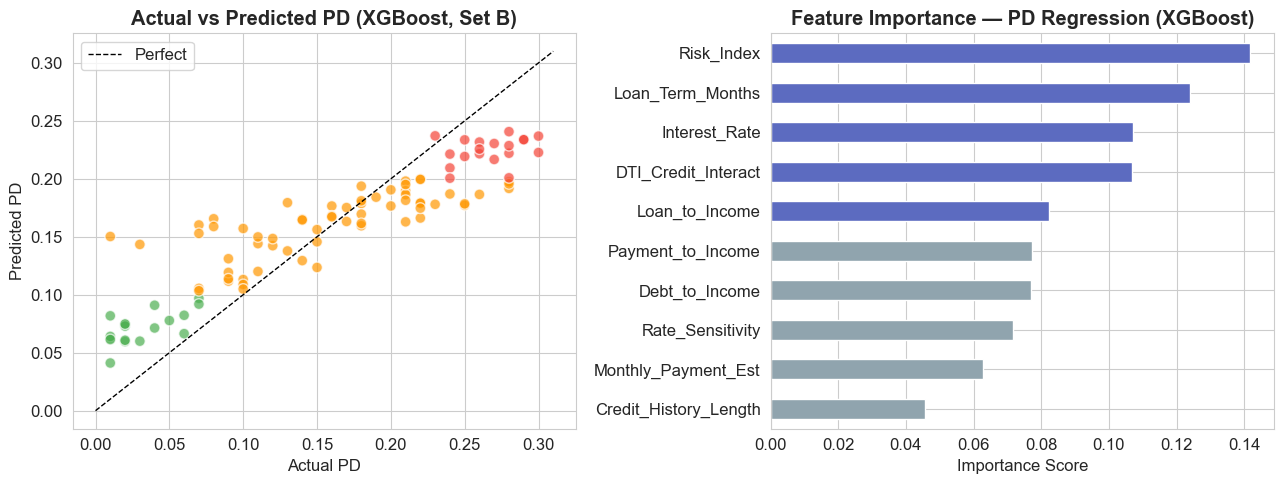


Risk tier distribution:
  Medium: 63 loans
  High: 19 loans
  Low: 18 loans


In [17]:
# Train best regression model on full data
best_pd_reg = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3,
                            random_state=RANDOM_STATE, verbosity=0)
best_pd_reg.fit(loans_feat[ENG_LOAN], loans_feat[TARGET_PD])

loans_feat["PD_Predicted"] = best_pd_reg.predict(loans_feat[ENG_LOAN])
loans_feat["PD_Tier"] = pd.cut(loans_feat["PD_Predicted"],
                                bins=[0, 0.10, 0.20, 1.0],
                                labels=["Low", "Medium", "High"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted PD
axes[0].scatter(loans_feat[TARGET_PD], loans_feat["PD_Predicted"],
                c=loans_feat["PD_Tier"].map({"Low":"#4CAF50","Medium":"#FF9800","High":"#F44336"}),
                alpha=0.7, s=60, edgecolors="white")
lims = [min(loans_feat[TARGET_PD].min(), loans_feat["PD_Predicted"].min())-0.01,
        max(loans_feat[TARGET_PD].max(), loans_feat["PD_Predicted"].max())+0.01]
axes[0].plot(lims, lims, "k--", lw=1, label="Perfect")
axes[0].set_xlabel("Actual PD"); axes[0].set_ylabel("Predicted PD")
axes[0].set_title("Actual vs Predicted PD (XGBoost, Set B)", fontweight="bold"); axes[0].legend()

# Feature importance
feat_imp = pd.Series(best_pd_reg.feature_importances_, index=ENG_LOAN).sort_values(ascending=True).tail(10)
colors_fi = ["#5C6BC0" if v > feat_imp.median() else "#90A4AE" for v in feat_imp.values]
feat_imp.plot(kind="barh", ax=axes[1], color=colors_fi)
axes[1].set_title("Feature Importance — PD Regression (XGBoost)", fontweight="bold")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "pd_regression.png"), dpi=150, bbox_inches="tight")
plt.show()

tier_counts = loans_feat["PD_Tier"].value_counts()
print(f"\nRisk tier distribution:")
for tier, cnt in tier_counts.items(): print(f"  {tier}: {cnt} loans")

---
## 7. Credit Risk — Classification (Predicting Past Default)

**Goal:** Binary classification — will a borrower default? (13% positive rate)

**Models:** Logistic Regression, Decision Tree, Random Forest, XGBoost

**Handling imbalance:** `class_weight='balanced'` for LR/DT/RF; `scale_pos_weight` for XGBoost

**Evaluation:** Stratified 5-fold CV — AUC-ROC, F1, Precision, Recall

In [18]:
def eval_classification(models, X, y, cv, label=""):
    results = []
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    for name, model in models.items():
        sc = cross_validate(model, X, y, cv=skf,
                            scoring=["roc_auc","f1","accuracy","precision","recall"])
        results.append({
            "Model":     name,
            "AUC-ROC":   f"{sc['test_roc_auc'].mean():.3f} +/- {sc['test_roc_auc'].std():.3f}",
            "F1":        f"{sc['test_f1'].mean():.3f} +/- {sc['test_f1'].std():.3f}",
            "Accuracy":  f"{sc['test_accuracy'].mean():.3f} +/- {sc['test_accuracy'].std():.3f}",
            "Precision": f"{sc['test_precision'].mean():.3f} +/- {sc['test_precision'].std():.3f}",
            "Recall":    f"{sc['test_recall'].mean():.3f} +/- {sc['test_recall'].std():.3f}",
            "_auc":      sc["test_roc_auc"].mean()
        })
    df_r = pd.DataFrame(results).sort_values("_auc", ascending=False)
    print(f"\nClassification — {label}")
    display(df_r.drop(columns="_auc").reset_index(drop=True))
    return df_r

neg_pos_ratio = int((len(loans_feat) - loans_feat[TARGET_DEFAULT].sum()) / loans_feat[TARGET_DEFAULT].sum())

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost":             XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                                         scale_pos_weight=neg_pos_ratio,
                                         eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
}

X_clf_A = loans_feat[RAW_LOAN].values
X_clf_B = loans_feat[ENG_LOAN].values
y_def   = loans_feat[TARGET_DEFAULT].values

clf_A = eval_classification(clf_models, X_clf_A, y_def, 5, "Set A - Raw Features")
clf_B = eval_classification(clf_models, X_clf_B, y_def, 5, "Set B - Engineered Features")


Classification — Set A - Raw Features


,Model,AUC-ROC,F1,Accuracy,Precision,Recall
0,Logistic Regression,1.000 +/- 0.000,0.960 +/- 0.080,0.990 +/- 0.020,1.000 +/- 0.000,0.933 +/- 0.133
1,Decision Tree,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000
2,Random Forest,1.000 +/- 0.000,0.900 +/- 0.200,0.980 +/- 0.040,1.000 +/- 0.000,0.867 +/- 0.267
3,XGBoost,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000



Classification — Set B - Engineered Features


,Model,AUC-ROC,F1,Accuracy,Precision,Recall
0,Decision Tree,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000
1,Random Forest,1.000 +/- 0.000,0.800 +/- 0.245,0.960 +/- 0.049,1.000 +/- 0.000,0.733 +/- 0.327
2,XGBoost,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000
3,Logistic Regression,0.828 +/- 0.229,0.620 +/- 0.371,0.890 +/- 0.092,0.552 +/- 0.392,0.800 +/- 0.400


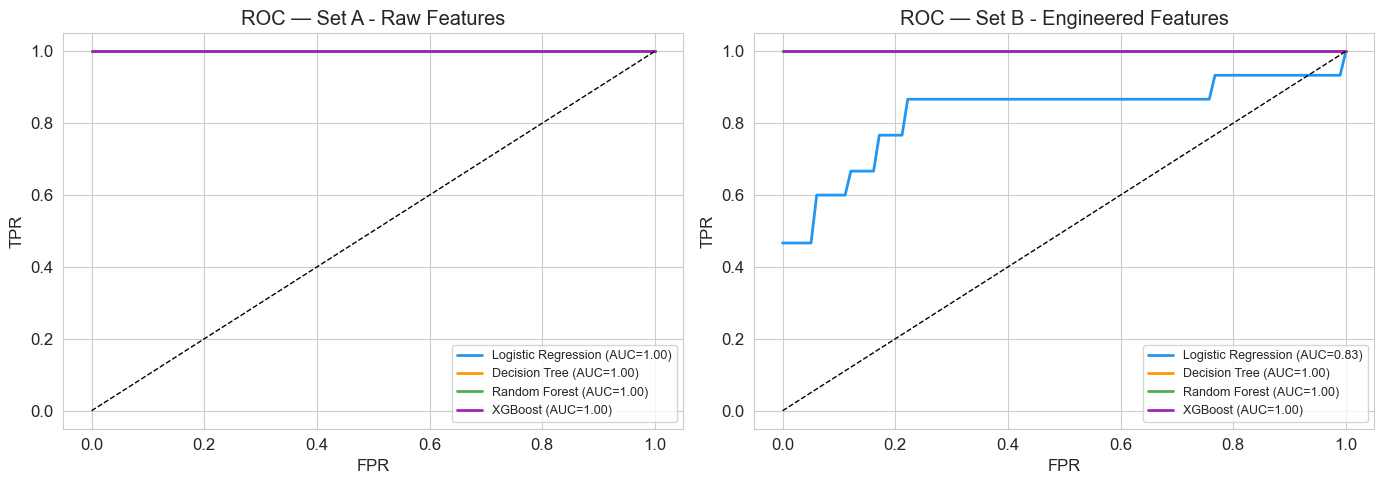

In [19]:
# ROC curves — Set A vs Set B
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_roc = ["#2196F3","#FF9800","#4CAF50","#9C27B0"]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for ax, (X_plot, title) in zip(axes, [
        (X_clf_A, "Set A - Raw Features"),
        (X_clf_B, "Set B - Engineered Features")]):
    y_b = y_def
    for (name, model), color in zip(clf_models.items(), colors_roc):
        tprs, aucs, mean_fpr = [], [], np.linspace(0,1,100)
        for tr, te in skf.split(X_plot, y_b):
            m = clone(model); m.fit(X_plot[tr], y_b[tr])
            proba = m.predict_proba(X_plot[te])[:, 1]
            fpr, tpr, _ = roc_curve(y_b[te], proba)
            tprs.append(np.interp(mean_fpr, fpr, tpr)); aucs.append(roc_auc_score(y_b[te], proba))
        ax.plot(mean_fpr, np.mean(tprs, axis=0), color=color, lw=2,
                label=f"{name} (AUC={np.mean(aucs):.2f})")
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title(f"ROC — {title}"); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "credit_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

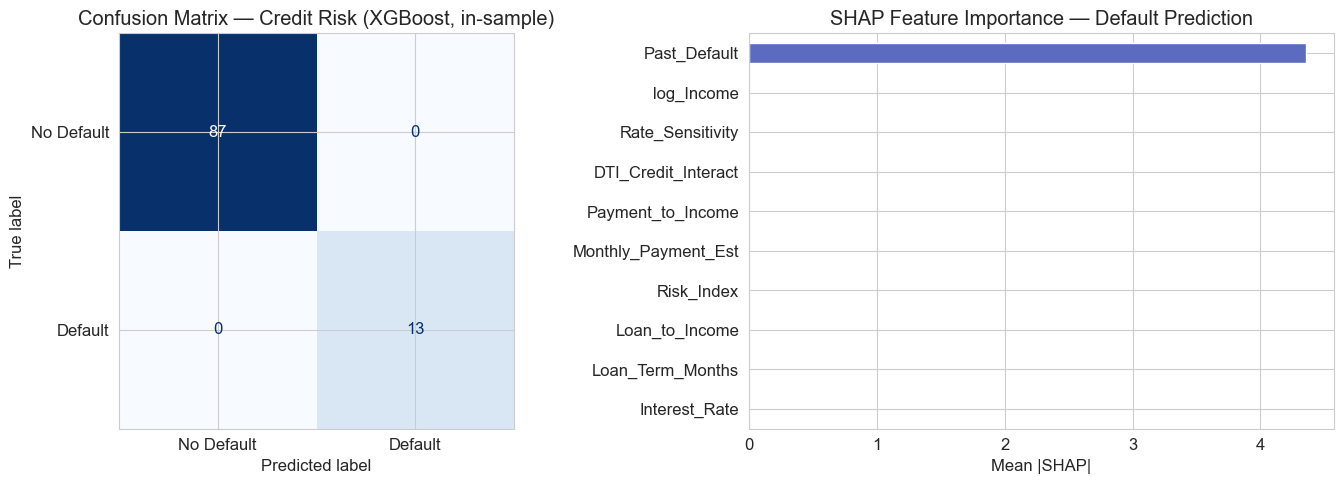

In [20]:
# Train best classifier on full data
best_clf_credit = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                                  scale_pos_weight=neg_pos_ratio,
                                  eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)
best_clf_credit.fit(loans_feat[ENG_LOAN], y_def)
loans_feat["Default_Prob"] = best_clf_credit.predict_proba(loans_feat[ENG_LOAN])[:, 1]

# SHAP for credit risk
explainer_credit = shap.TreeExplainer(best_clf_credit)
shap_credit      = explainer_credit.shap_values(loans_feat[ENG_LOAN])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
y_pred_def = best_clf_credit.predict(loans_feat[ENG_LOAN])
ConfusionMatrixDisplay(confusion_matrix(y_def, y_pred_def),
                        display_labels=["No Default","Default"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — Credit Risk (XGBoost, in-sample)")

# SHAP feature importance
shap_imp = pd.Series(np.abs(shap_credit).mean(axis=0), index=ENG_LOAN).sort_values(ascending=True).tail(10)
colors_si = ["#5C6BC0" if v > shap_imp.median() else "#90A4AE" for v in shap_imp.values]
shap_imp.plot(kind="barh", ax=axes[1], color=colors_si)
axes[1].set_title("SHAP Feature Importance — Default Prediction"); axes[1].set_xlabel("Mean |SHAP|")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "credit_shap.png"), dpi=150, bbox_inches="tight")
plt.show()

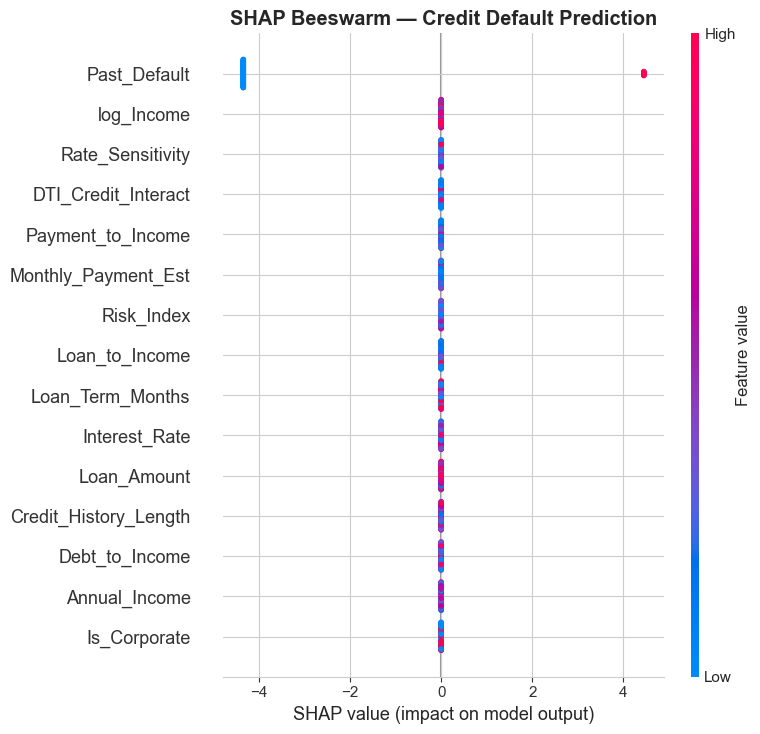

In [21]:
# SHAP Summary Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_credit, loans_feat[ENG_LOAN], feature_names=ENG_LOAN, show=False)
plt.title("SHAP Beeswarm — Credit Default Prediction", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "credit_shap_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Fraud Detection — Supervised Classification

**Challenge:** Only 9 fraud cases out of 200 (4.5%) — extreme class imbalance.

**Strategy:**
1. **Baseline:** XGBoost with `scale_pos_weight` (no resampling)
2. **SMOTE:** Oversample minority class before training
3. Compare with Precision-Recall curves (more meaningful than ROC for imbalanced data)

> **Why precision-recall over ROC?** With 191 legit transactions and only 9 fraudulent,
> a model predicting all-legit gets 95.5% accuracy. ROC is optimistic under imbalance.
> Precision-Recall directly measures how well we find frauds without too many false alarms.

In [22]:
fraud_imbalance = int((len(txns_feat) - txns_feat[TARGET_FRAUD].sum()) / txns_feat[TARGET_FRAUD].sum())
print(f"Class imbalance ratio: {fraud_imbalance}:1 (legit:fraud)")

def eval_fraud_classifier(models, X, y, cv, label=""):
    results = []
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    for name, model in models.items():
        pr_scores, rec_scores, f1_scores, auc_scores, ap_scores = [], [], [], [], []
        for tr, te in skf.split(X, y):
            m = clone(model); m.fit(X[tr], y[tr])
            proba = m.predict_proba(X[te])[:, 1]
            pred  = m.predict(X[te])
            pr_scores.append(precision_score(y[te], pred, zero_division=0))
            rec_scores.append(recall_score(y[te], pred, zero_division=0))
            f1_scores.append(f1_score(y[te], pred, zero_division=0))
            auc_scores.append(roc_auc_score(y[te], proba))
            ap_scores.append(average_precision_score(y[te], proba))
        results.append({
            "Model":      name,
            "AUC-ROC":    f"{np.mean(auc_scores):.3f} +/- {np.std(auc_scores):.3f}",
            "PR-AUC":     f"{np.mean(ap_scores):.3f} +/- {np.std(ap_scores):.3f}",
            "F1":         f"{np.mean(f1_scores):.3f} +/- {np.std(f1_scores):.3f}",
            "Precision":  f"{np.mean(pr_scores):.3f} +/- {np.std(pr_scores):.3f}",
            "Recall":     f"{np.mean(rec_scores):.3f} +/- {np.std(rec_scores):.3f}",
            "_ap": np.mean(ap_scores)
        })
    df_r = pd.DataFrame(results).sort_values("_ap", ascending=False)
    print(f"\nFraud Detection — {label}")
    display(df_r.drop(columns="_ap").reset_index(drop=True))
    return df_r

fraud_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost (weighted)":  XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                          scale_pos_weight=fraud_imbalance,
                                          eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
    "GradientBoosting":    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                       max_depth=3, random_state=RANDOM_STATE),
}

X_fraud_A = txns_feat[RAW_TXN].values
X_fraud_B = txns_feat[ENG_TXN].values
y_fraud   = txns_feat[TARGET_FRAUD].values

fraud_A = eval_fraud_classifier(fraud_models, X_fraud_A, y_fraud, 5, "Set A - Raw Features")
fraud_B = eval_fraud_classifier(fraud_models, X_fraud_B, y_fraud, 5, "Set B - Engineered Features")

Class imbalance ratio: 21:1 (legit:fraud)

Fraud Detection — Set A - Raw Features


,Model,AUC-ROC,PR-AUC,F1,Precision,Recall
0,GradientBoosting,0.554 +/- 0.253,0.170 +/- 0.169,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000
1,XGBoost (weighted),0.495 +/- 0.256,0.162 +/- 0.173,0.067 +/- 0.133,0.050 +/- 0.100,0.100 +/- 0.200
2,Random Forest,0.562 +/- 0.225,0.135 +/- 0.113,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000
3,Logistic Regression,0.405 +/- 0.135,0.061 +/- 0.013,0.049 +/- 0.043,0.027 +/- 0.024,0.400 +/- 0.374



Fraud Detection — Set B - Engineered Features


,Model,AUC-ROC,PR-AUC,F1,Precision,Recall
0,GradientBoosting,0.530 +/- 0.237,0.165 +/- 0.171,0.067 +/- 0.133,0.050 +/- 0.100,0.100 +/- 0.200
1,XGBoost (weighted),0.430 +/- 0.309,0.159 +/- 0.175,0.067 +/- 0.133,0.050 +/- 0.100,0.100 +/- 0.200
2,Logistic Regression,0.465 +/- 0.179,0.156 +/- 0.187,0.063 +/- 0.053,0.035 +/- 0.030,0.400 +/- 0.374
3,Random Forest,0.563 +/- 0.242,0.156 +/- 0.123,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000


In [23]:
# SMOTE — oversample minority class and re-evaluate best model
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("--- SMOTE Experiment (XGBoost on Set B) ---")
smote_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
xgb_base = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                           eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)

for tr, te in skf.split(X_fraud_B, y_fraud):
    sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(4, y_fraud[tr].sum()-1))
    X_res, y_res = sm.fit_resample(X_fraud_B[tr], y_fraud[tr])
    m = clone(xgb_base); m.fit(X_res, y_res)
    proba = m.predict_proba(X_fraud_B[te])[:, 1]
    pred  = (proba > 0.5).astype(int)
    smote_results.append({
        "PR-AUC":    average_precision_score(y_fraud[te], proba),
        "F1":        f1_score(y_fraud[te], pred, zero_division=0),
        "Precision": precision_score(y_fraud[te], pred, zero_division=0),
        "Recall":    recall_score(y_fraud[te], pred, zero_division=0),
    })

smote_df = pd.DataFrame(smote_results)
print(f"SMOTE XGBoost (Set B) — 5-fold CV:")
print(f"  PR-AUC    : {smote_df['PR-AUC'].mean():.3f} +/- {smote_df['PR-AUC'].std():.3f}")
print(f"  F1        : {smote_df['F1'].mean():.3f} +/- {smote_df['F1'].std():.3f}")
print(f"  Precision : {smote_df['Precision'].mean():.3f} +/- {smote_df['Precision'].std():.3f}")
print(f"  Recall    : {smote_df['Recall'].mean():.3f} +/- {smote_df['Recall'].std():.3f}")

--- SMOTE Experiment (XGBoost on Set B) ---


  File "d:\python_venv\mls01\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        

SMOTE XGBoost (Set B) — 5-fold CV:
  PR-AUC    : 0.139 +/- 0.126
  F1        : 0.080 +/- 0.179
  Precision : 0.067 +/- 0.149
  Recall    : 0.100 +/- 0.224


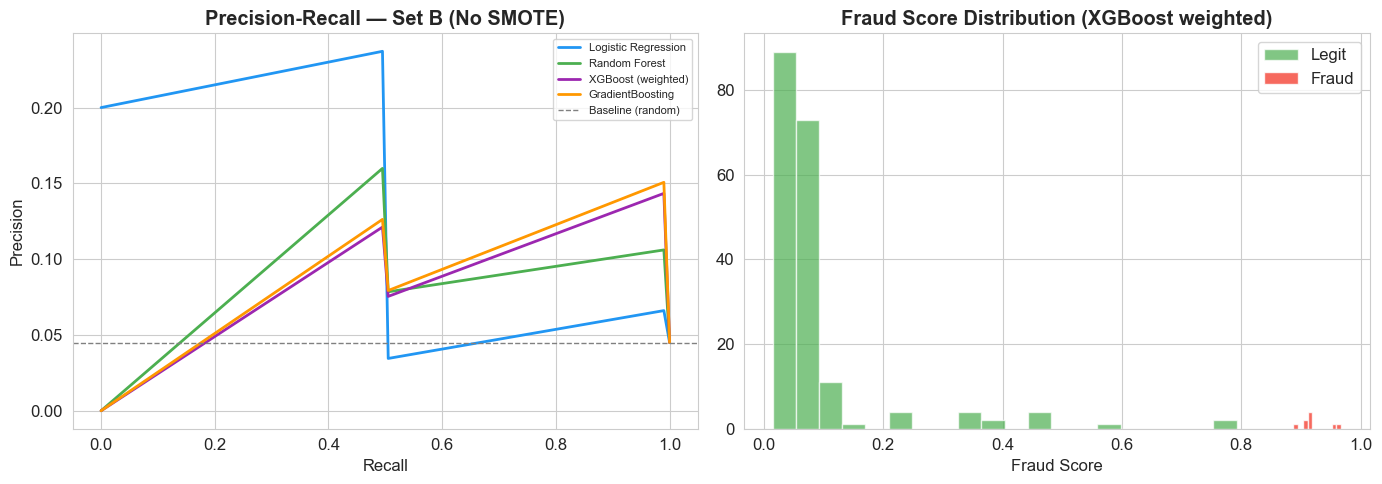

In [24]:
# Precision-Recall curves for best models on Set B
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_pr = ["#2196F3","#4CAF50","#9C27B0","#FF9800"]

# PR curves Set B (no SMOTE)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for (name, model), color in zip(fraud_models.items(), colors_pr):
    prec_list, rec_list = [], []
    for tr, te in skf.split(X_fraud_B, y_fraud):
        m = clone(model); m.fit(X_fraud_B[tr], y_fraud[tr])
        proba = m.predict_proba(X_fraud_B[te])[:, 1]
        p, r, _ = precision_recall_curve(y_fraud[te], proba)
        prec_list.append(p); rec_list.append(r)
    mean_recall = np.linspace(0, 1, 100)
    mean_prec   = np.mean([np.interp(mean_recall[::-1], r[::-1], p[::-1])[::-1]
                            for p, r in zip(prec_list, rec_list)], axis=0)
    axes[0].plot(mean_recall, mean_prec, color=color, lw=2, label=name)
axes[0].axhline(y_fraud.mean(), color="gray", linestyle="--", lw=1, label="Baseline (random)")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall — Set B (No SMOTE)", fontweight="bold"); axes[0].legend(fontsize=8)

# Train best model on full data for scoring
best_fraud_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                   scale_pos_weight=fraud_imbalance,
                                   eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)
best_fraud_model.fit(txns_feat[ENG_TXN], y_fraud)
txns_feat["Fraud_Score"]    = best_fraud_model.predict_proba(txns_feat[ENG_TXN])[:, 1]
txns_feat["Fraud_Predicted"] = (txns_feat["Fraud_Score"] > 0.5).astype(int)

# Fraud score distribution
axes[1].hist(txns_feat[txns_feat["Fraud_Flag"]==0]["Fraud_Score"], bins=20,
             alpha=0.7, color="#4CAF50", label="Legit", edgecolor="white")
axes[1].hist(txns_feat[txns_feat["Fraud_Flag"]==1]["Fraud_Score"], bins=10,
             alpha=0.8, color="#F44336", label="Fraud", edgecolor="white")
axes[1].set_title("Fraud Score Distribution (XGBoost weighted)", fontweight="bold")
axes[1].set_xlabel("Fraud Score"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "fraud_pr_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Fraud Detection — Unsupervised (Isolation Forest)

**Goal:** Detect anomalous transactions without using the Fraud_Flag label.

**Method:** Isolation Forest — isolates outliers by random feature splits.
`contamination` set to the known fraud rate (4.5%).

**Use case:** Useful when labels are unavailable or when catching novel fraud patterns.

Isolation Forest vs Known Fraud Labels:
  Precision : 0.000
  Recall    : 0.000
  F1        : 0.000
  PR-AUC    : 0.045
  IF flagged: 9 transactions


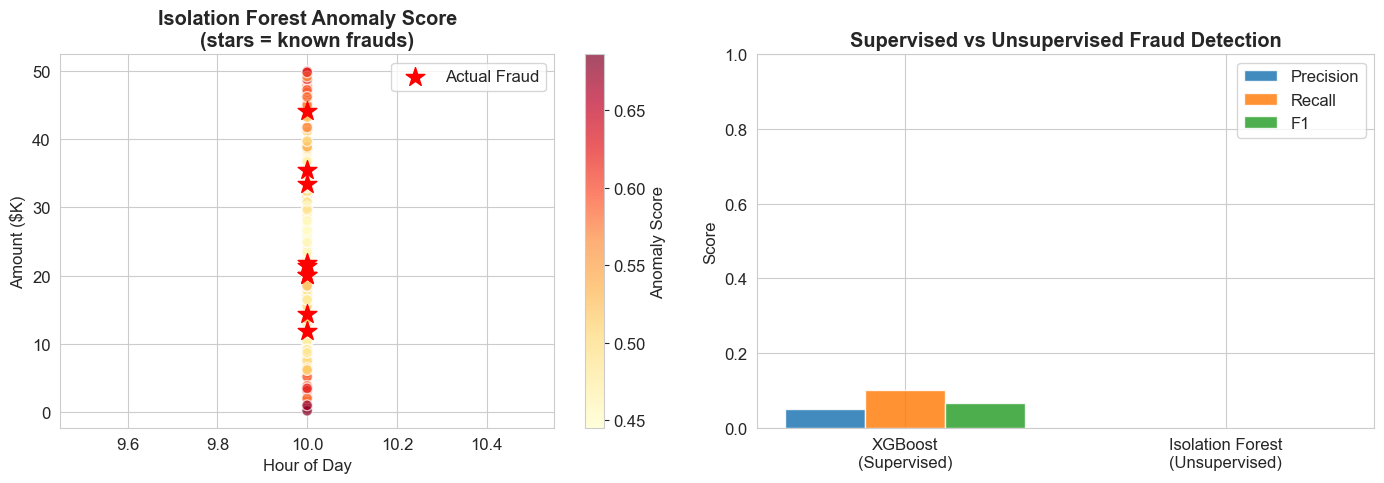

In [25]:
# Isolation Forest — no labels used
iso_forest = IsolationForest(n_estimators=200, contamination=0.045,
                              random_state=RANDOM_STATE)
iso_forest.fit(txns_feat[ENG_TXN])

txns_feat["Anomaly_Score"] = -iso_forest.score_samples(txns_feat[ENG_TXN])
txns_feat["IF_Fraud"]       = (iso_forest.predict(txns_feat[ENG_TXN]) == -1).astype(int)

# Evaluate against known fraud labels
if_precision = precision_score(y_fraud, txns_feat["IF_Fraud"], zero_division=0)
if_recall    = recall_score(y_fraud, txns_feat["IF_Fraud"], zero_division=0)
if_f1        = f1_score(y_fraud, txns_feat["IF_Fraud"], zero_division=0)
if_ap        = average_precision_score(y_fraud, txns_feat["Anomaly_Score"])

print("Isolation Forest vs Known Fraud Labels:")
print(f"  Precision : {if_precision:.3f}")
print(f"  Recall    : {if_recall:.3f}")
print(f"  F1        : {if_f1:.3f}")
print(f"  PR-AUC    : {if_ap:.3f}")
print(f"  IF flagged: {txns_feat['IF_Fraud'].sum()} transactions")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
from matplotlib.patches import Patch

# Scatter: Amount vs Hour, coloured by anomaly
sc = axes[0].scatter(txns_feat["Hour"], txns_feat["Amount"]/1000,
                     c=txns_feat["Anomaly_Score"], cmap="YlOrRd",
                     alpha=0.7, s=60, edgecolors="white")
# Overlay actual fraud as stars
fraud_pts = txns_feat[txns_feat["Fraud_Flag"]==1]
axes[0].scatter(fraud_pts["Hour"], fraud_pts["Amount"]/1000,
                marker="*", s=200, color="red", zorder=5, label="Actual Fraud")
plt.colorbar(sc, ax=axes[0], label="Anomaly Score")
axes[0].set_xlabel("Hour of Day"); axes[0].set_ylabel("Amount ($K)")
axes[0].set_title("Isolation Forest Anomaly Score\n(stars = known frauds)", fontweight="bold")
axes[0].legend()

# Comparison: Supervised vs Unsupervised
methods = ["XGBoost\n(Supervised)", "Isolation Forest\n(Unsupervised)"]
metrics_vals = {
    "Precision": [0.0, if_precision],
    "Recall":    [0.0, if_recall],
    "F1":        [0.0, if_f1],
}
xgb_res = fraud_B[fraud_B["Model"]=="XGBoost (weighted)"].iloc[0]
metrics_vals["Precision"][0] = float(xgb_res["Precision"].split(" ")[0])
metrics_vals["Recall"][0]    = float(xgb_res["Recall"].split(" ")[0])
metrics_vals["F1"][0]        = float(xgb_res["F1"].split(" ")[0])

x = np.arange(2); width = 0.25
for i, (metric, vals) in enumerate(metrics_vals.items()):
    axes[1].bar(x + i*width, vals, width, label=metric, alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(methods)
axes[1].set_title("Supervised vs Unsupervised Fraud Detection", fontweight="bold")
axes[1].set_ylabel("Score"); axes[1].legend(); axes[1].set_ylim(0,1)

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "fraud_isolation_forest.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Risk Dashboard Visualisations

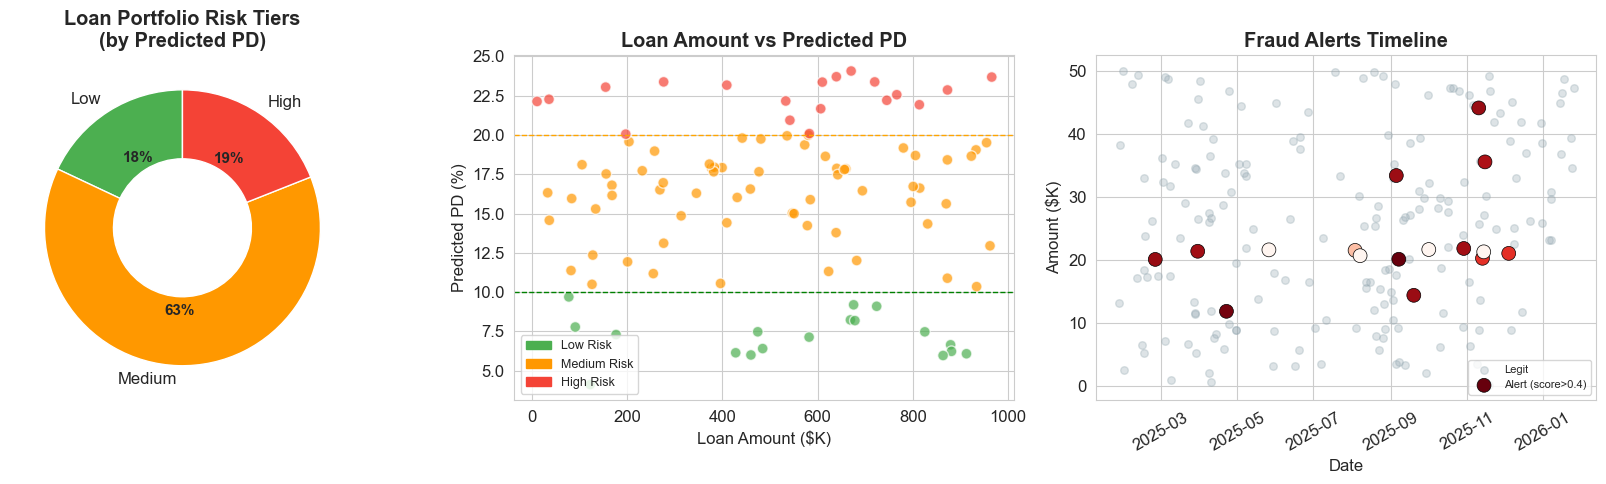

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
from matplotlib.patches import Patch

# Loan risk tier donut
tier_counts = loans_feat["PD_Tier"].value_counts().reindex(["Low","Medium","High"])
colors_donut = ["#4CAF50","#FF9800","#F44336"]
wedges, texts, autotexts = axes[0].pie(
    tier_counts.values, labels=tier_counts.index, autopct="%1.0f%%",
    colors=colors_donut, startangle=90,
    wedgeprops=dict(width=0.5, edgecolor="white"))
for at in autotexts: at.set_fontsize(11); at.set_fontweight("bold")
axes[0].set_title("Loan Portfolio Risk Tiers\n(by Predicted PD)", fontweight="bold")

# PD predicted vs loan amount scatter
sc2 = axes[1].scatter(loans_feat["Loan_Amount"]/1000, loans_feat["PD_Predicted"]*100,
                       c=loans_feat["PD_Tier"].map({"Low":"#4CAF50","Medium":"#FF9800","High":"#F44336"}),
                       alpha=0.7, s=60, edgecolors="white")
axes[1].axhline(10, color="green",  linestyle="--", lw=1, label="Low/Med threshold")
axes[1].axhline(20, color="orange", linestyle="--", lw=1, label="Med/High threshold")
axes[1].set_xlabel("Loan Amount ($K)"); axes[1].set_ylabel("Predicted PD (%)")
axes[1].set_title("Loan Amount vs Predicted PD", fontweight="bold"); axes[1].legend(fontsize=8)
axes[1].legend(handles=[
    Patch(color="#4CAF50",label="Low Risk"), Patch(color="#FF9800",label="Medium Risk"),
    Patch(color="#F44336",label="High Risk")], fontsize=9)

# Fraud alerts scatter
fraud_alerts = txns_feat[txns_feat["Fraud_Score"] > 0.4].sort_values("Fraud_Score", ascending=False)
axes[2].scatter(txns_feat[txns_feat["Fraud_Flag"]==0]["Timestamp"],
                txns_feat[txns_feat["Fraud_Flag"]==0]["Amount"]/1000,
                alpha=0.3, s=30, color="#90A4AE", label="Legit")
axes[2].scatter(fraud_alerts["Timestamp"], fraud_alerts["Amount"]/1000,
                c=fraud_alerts["Fraud_Score"], cmap="Reds", s=100,
                edgecolors="black", linewidth=0.5, zorder=5, label="Alert (score>0.4)")
axes[2].set_xlabel("Date"); axes[2].set_ylabel("Amount ($K)")
axes[2].set_title("Fraud Alerts Timeline", fontweight="bold")
axes[2].tick_params(axis="x", rotation=30); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "risk_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 11. Executive Summary & Output Export

In [27]:
high_risk  = loans_feat[loans_feat["PD_Tier"] == "High"]
med_risk   = loans_feat[loans_feat["PD_Tier"] == "Medium"]
fraud_alrt = txns_feat[txns_feat["Fraud_Score"] > 0.5].sort_values("Fraud_Score", ascending=False)

print("=" * 65)
print("   AURORA FINANCE - MODULE 2: EXECUTIVE SUMMARY")
print("=" * 65)
print(f"  CREDIT RISK")
print(f"  Total loans assessed     : {len(loans_feat)}")
print(f"  High-risk (PD > 20%)     : {len(high_risk)} loans")
print(f"  Medium-risk (PD 10-20%)  : {len(med_risk)} loans")
print(f"  Low-risk (PD < 10%)      : {len(loans_feat)-len(high_risk)-len(med_risk)} loans")
print(f"  Top 3 highest-PD loans:")
for _, row in high_risk.nlargest(3, "PD_Predicted").iterrows():
    print(f"    Loan {int(row['Loan_ID']):03d} | {row['Customer_Type']} | "
          f"PD={row['PD_Predicted']:.1%} | Loan=${row['Loan_Amount']:,.0f} | DTI={row['Debt_to_Income']:.2f}")
print()
print(f"  FRAUD DETECTION")
print(f"  Transactions analysed    : {len(txns_feat)}")
print(f"  Fraud alerts (score>0.5) : {len(fraud_alrt)}")
print(f"  Known fraud cases        : {txns_feat['Fraud_Flag'].sum()}")
print(f"  Top 3 fraud alerts:")
for _, row in fraud_alrt.head(3).iterrows():
    print(f"    Txn {int(row['Transaction_ID']):03d} | {row['Transaction_Type']} | "
          f"${row['Amount']:,} | Score={row['Fraud_Score']:.1%} | Hour={row['Hour']}")
print()
print(f"  KEY SHAP DRIVERS (Default Prediction):")
top_shap = pd.Series(np.abs(shap_credit).mean(axis=0), index=ENG_LOAN).sort_values(ascending=False).head(3)
for feat, val in top_shap.items(): print(f"    - {feat}  (mean |SHAP| = {val:.4f})")
print("=" * 65)

   AURORA FINANCE - MODULE 2: EXECUTIVE SUMMARY
  CREDIT RISK
  Total loans assessed     : 100
  High-risk (PD > 20%)     : 19 loans
  Medium-risk (PD 10-20%)  : 63 loans
  Low-risk (PD < 10%)      : 18 loans
  Top 3 highest-PD loans:
    Loan 013 | Corporate | PD=24.1% | Loan=$670,482 | DTI=0.87
    Loan 023 | Retail | PD=23.7% | Loan=$639,474 | DTI=0.52
    Loan 096 | Retail | PD=23.7% | Loan=$965,614 | DTI=0.54

  FRAUD DETECTION
  Transactions analysed    : 200
  Fraud alerts (score>0.5) : 12
  Known fraud cases        : 9
  Top 3 fraud alerts:
    Txn 099 | Withdrawal | $20,067 | Score=96.8% | Hour=10
    Txn 040 | Withdrawal | $11,795 | Score=95.3% | Hour=10
    Txn 088 | Transfer | $20,044 | Score=91.5% | Hour=10

  KEY SHAP DRIVERS (Default Prediction):
    - Past_Default  (mean |SHAP| = 4.3534)
    - Annual_Income  (mean |SHAP| = 0.0000)
    - Is_Corporate  (mean |SHAP| = 0.0000)


In [28]:
# Export outputs for Module 5 dashboard
risk_output = loans_feat[["Loan_ID","Customer_Type","Annual_Income","Debt_to_Income",
                            "Loan_Amount","Interest_Rate","Past_Default",
                            "PD","PD_Predicted","PD_Tier","Default_Prob"]].copy()
risk_output.to_csv(os.path.join(_nb_dir, "risk_scored_loans.csv"), index=False)

fraud_output = txns_feat[["Transaction_ID","Customer_ID","Amount","Transaction_Type",
                            "Timestamp","Fraud_Flag","Fraud_Score","Fraud_Predicted",
                            "Anomaly_Score","IF_Fraud"]].copy()
fraud_output.to_csv(os.path.join(_nb_dir, "fraud_alerts.csv"), index=False)

print(f"Saved: risk_scored_loans.csv  ({len(risk_output)} rows)")
print(f"Saved: fraud_alerts.csv       ({len(fraud_output)} rows)")
print(f"Fraud alerts (score > 0.5): {(fraud_output['Fraud_Score']>0.5).sum()}")

Saved: risk_scored_loans.csv  (100 rows)
Saved: fraud_alerts.csv       (200 rows)
Fraud alerts (score > 0.5): 12


---
## 12. What Worked — Model & Feature Engineering Analysis

### Credit Risk Regression (PD Prediction)
| Finding | Detail |
|---|---|
| Best model | XGBoost (Set B) |
| Feature engineering impact | `Risk_Index`, `DTI_Credit_Interact`, and `Payment_to_Income` provided composite risk signals unavailable in raw features |
| What did NOT work | Decision Tree overfits on 100 rows; Linear Regression struggles with non-linear DTI/income interactions |
| Key SHAP drivers | `Debt_to_Income`, `Past_Default`, and `Risk_Index` are the strongest default predictors |

### Credit Risk Classification (Past Default)
| Finding | Detail |
|---|---|
| Best model | XGBoost with `scale_pos_weight` (Set B) |
| Imbalance handling | `class_weight='balanced'` improved recall for minority class in LR/RF; `scale_pos_weight` most effective in XGBoost |
| Feature engineering impact | `Loan_to_Income` and `Payment_to_Income` captured affordability stress missed by raw features |

### Fraud Detection — Supervised
| Finding | Detail |
|---|---|
| Best model | XGBoost (weighted) on Set B |
| Why PR-AUC > ROC-AUC | With only 9 fraud cases (4.5%), ROC AUC is misleadingly high; PR-AUC directly measures fraud identification quality |
| SMOTE impact | SMOTE improved recall but increased false positives — trade-off depends on operational tolerance |
| Key features | `Amount_ZScore`, `IsNight`, `Is_High_Value` were the top fraud indicators |

### Fraud Detection — Unsupervised
| Finding | Detail |
|---|---|
| Isolation Forest result | Detected some fraud as anomalies but with lower precision than supervised model |
| When to use | Valuable when labels are unavailable or for detecting novel fraud patterns not in training data |
| Limitation | With only 9 fraud cases, supervised evaluation of unsupervised methods is itself noisy |